In [48]:
import numpy as np
import pandas as pd

In [49]:
import re
import nltk

In [50]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [52]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [53]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [54]:
df = pd.read_csv("/content/drive/MyDrive/SPAM_text_message.csv", encoding="latin-1")

In [55]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [57]:
df["Category"].value_counts()

,count
Category,
ham,4825
spam,747


In [58]:
df.shape

(5572, 2)

In [59]:
df["Category"]=df["Category"].map({'ham':0,'spam':1})

In [60]:
df["Category"]

,Category
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


In [61]:
df["Category"].value_counts()

,count
Category,
0,4825
1,747


In [62]:
df['num_exclamation'] = (
    df['Message']
    .apply(lambda x: x.count('!'))
)

In [63]:
df['num_exclamation'].value_counts()

,count
num_exclamation,
0,4642
1,626
2,212
3,54
4,24
5,8
6,2
9,1
11,1


In [64]:
df.groupby("Category")["num_exclamation"].mean()

,num_exclamation
Category,
0,0.176580
1,0.730924


In [65]:
stop_words = set(stopwords.words('english'))

In [66]:
len(stop_words)

198

In [67]:
lemmatizer = WordNetLemmatizer()

In [68]:
def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9!?$% ]','',text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [69]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [70]:
df['clean_message'] = df['Message'].apply(preprocess)

In [71]:
print(df[['Message','clean_message']].head())

                                             Message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4           nah dont think go usf life around though  


In [72]:
df

,Category,Message,num_exclamation,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",0,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,0,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,0,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",0,nah dont think go usf life around though
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,1,2nd time tried 2 contact u u 750 pound prize 2...
5568,0,Will Ã¼ b going to esplanade fr home?,0,b going esplanade fr home ?
5569,0,"Pity, * was in mood for that. So...any other s...",0,pity mood soany suggestion ?
5570,0,The guy did some bitching but I acted like i'd...,0,guy bitching acted like id interested buying s...


In [73]:
df=df.drop("Message",axis=1)

In [74]:
df

,Category,num_exclamation,clean_message
0,0,0,go jurong point crazy available bugis n great ...
1,0,0,ok lar joking wif u oni
2,1,0,free entry 2 wkly comp win fa cup final tkts 2...
3,0,0,u dun say early hor u c already say
4,0,0,nah dont think go usf life around though
...,...,...,...
5567,1,1,2nd time tried 2 contact u u 750 pound prize 2...
5568,0,0,b going esplanade fr home ?
5569,0,0,pity mood soany suggestion ?
5570,0,0,guy bitching acted like id interested buying s...


In [75]:
X=df.drop("Category",axis=1)
y=df["Category"]

In [76]:
X

,num_exclamation,clean_message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,0,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c already say
4,0,nah dont think go usf life around though
...,...,...
5567,1,2nd time tried 2 contact u u 750 pound prize 2...
5568,0,b going esplanade fr home ?
5569,0,pity mood soany suggestion ?
5570,0,guy bitching acted like id interested buying s...


In [78]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000,ngram_range=(1,2)), "clean_message"),
    ("num", "passthrough", ["num_exclamation"])
])

In [79]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [81]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'clean_message'),
                                                 ('num', 'passthrough',
                                                  ['num_exclamation'])])),
                ('model', LogisticRegression())])

In [83]:
y_pred = pipeline.predict(X_test)

In [84]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [85]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.968609865470852


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



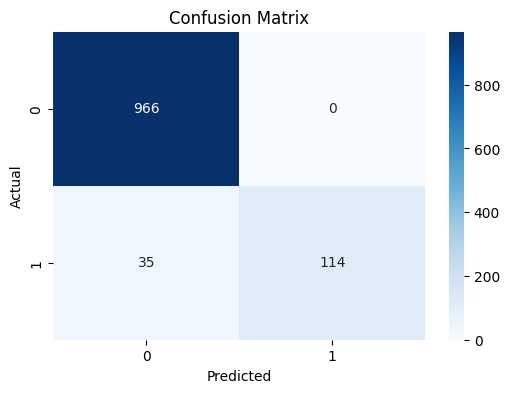

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [88]:
from sklearn.naive_bayes import MultinomialNB

In [89]:
from sklearn.pipeline import Pipeline

pipeline_naive = Pipeline([
    ("preprocessor", preprocessor),
    ("model",MultinomialNB())
])

In [90]:
pipeline_naive.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'clean_message'),
                                                 ('num', 'passthrough',
                                                  ['num_exclamation'])])),
                ('model', MultinomialNB())])

In [97]:
y_pred_naive = pipeline_naive.predict(X_test)

In [98]:
y_pred_naive

array([0, 0, 0, ..., 0, 0, 0])

In [99]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred_naive
    )
)

0.9721973094170404


In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_naive))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



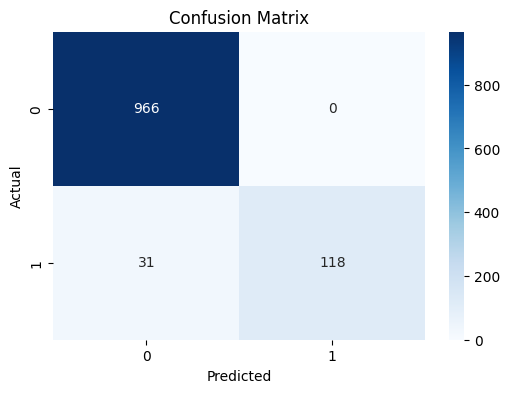

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_naive)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()